In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

In [21]:
# Define the paths to the folders containing images
red_head_folder = r"D:\New folder\prawns segmented data\v3\Bad"
white_head_folder = r"D:\New folder\prawns segmented data\v3\Good"

# Get image paths and labels for red head prawns
red_head_images = [os.path.join(red_head_folder, image) for image in os.listdir(red_head_folder)]
red_head_labels = ['red_head'] * len(red_head_images)

# Get image paths and labels for white head prawns
white_head_images = [os.path.join(white_head_folder, image) for image in os.listdir(white_head_folder)]
white_head_labels = ['white_head'] * len(white_head_images)

# Combine the paths and labels for both classes
image_paths = red_head_images + white_head_images
labels = red_head_labels + white_head_labels

# Create a DataFrame
data = pd.DataFrame({'image_path': image_paths, 'label': labels})


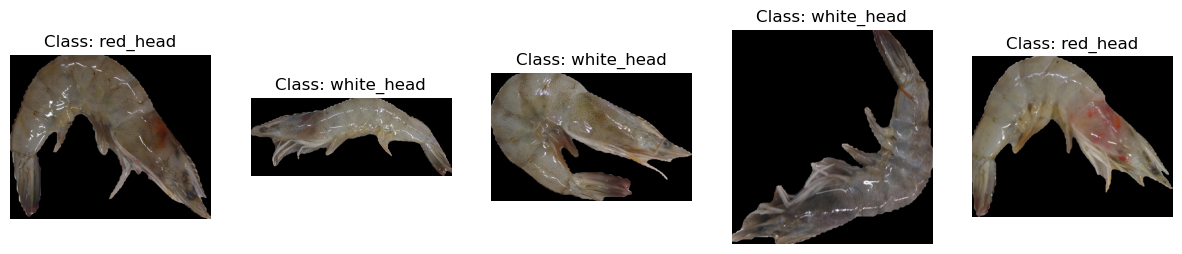

In [22]:
# Display a few sample images
def display_images(data, num_samples=5):
    plt.figure(figsize=(15, 3))
    sample_indices = np.random.choice(len(data), num_samples, replace=False)

    for i, index in enumerate(sample_indices):
        plt.subplot(1, num_samples, i + 1)
        img = Image.open(data.iloc[index]['image_path'])
        plt.imshow(img)
        plt.title(f"Class: {data.iloc[index]['label']}")
        plt.axis('off')
    
    plt.show()

# Display a few images from both classes
display_images(data)


In [23]:
data.shape

(82, 2)

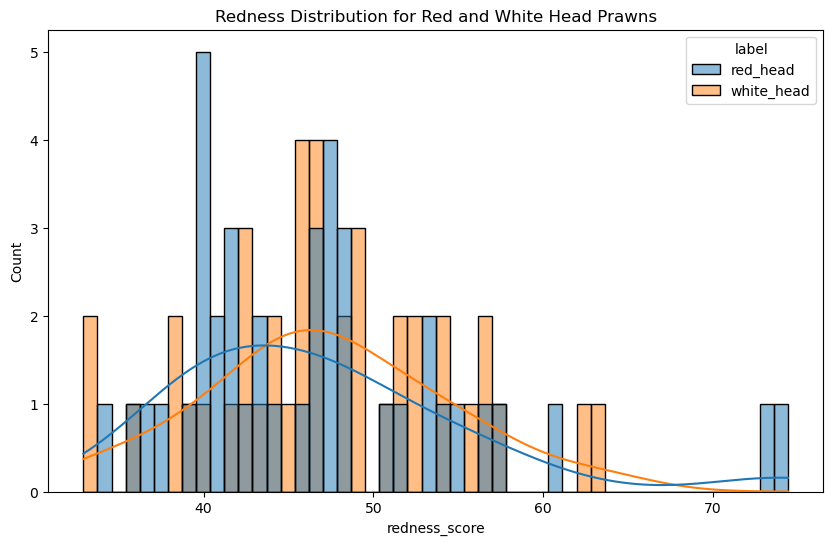

In [24]:
def calculate_redness(image_path):
    img = Image.open(image_path) #.convert("RGB")
    red_pixels = np.array(img)[:, :, 0]  # Extract red channel
    redness_score = np.mean(red_pixels)
    return redness_score

# Calculate redness scores for a sample of images
data['redness_score'] = data['image_path'].apply(calculate_redness)

# Visualize redness distribution for each class
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='redness_score', hue='label', kde=True, bins=50)
plt.title('Redness Distribution for Red and White Head Prawns')
plt.show()


In [25]:
red_summary = data.groupby('label')['redness_score'].describe()
print(red_summary)

            count       mean       std        min        25%        50%  \
label                                                                     
red_head     41.0  46.917369  8.790287  34.202012  40.548477  46.541452   
white_head   41.0  47.204420  7.145217  32.922862  42.481228  46.554013   

                  75%        max  
label                             
red_head    50.926432  74.403123  
white_head  51.566173  63.282426  


Epoch 1/20
3/3 [==============================] - 7s 2s/step - loss: 563.6599 - accuracy: 0.5077 - val_loss: 228.6454 - val_accuracy: 0.3529
Epoch 2/20
3/3 [==============================] - 3s 759ms/step - loss: 146.7103 - accuracy: 0.5385 - val_loss: 18.0833 - val_accuracy: 0.3529
Epoch 3/20
3/3 [==============================] - 3s 848ms/step - loss: 8.1840 - accuracy: 0.5538 - val_loss: 0.7507 - val_accuracy: 0.6471
Epoch 4/20
3/3 [==============================] - 4s 1s/step - loss: 0.4625 - accuracy: 0.7692 - val_loss: 0.6027 - val_accuracy: 0.7059
Epoch 5/20
3/3 [==============================] - 4s 1s/step - loss: 0.3379 - accuracy: 0.8769 - val_loss: 0.5518 - val_accuracy: 0.7647
Epoch 6/20
3/3 [==============================] - 4s 1s/step - loss: 0.1427 - accuracy: 0.9385 - val_loss: 1.9519 - val_accuracy: 0.5294
Epoch 7/20
3/3 [==============================] - 3s 961ms/step - loss: 0.3199 - accuracy: 0.8462 - val_loss: 2.5546 - val_accuracy: 0.7059
Epoch 8/20
3/3 [=========

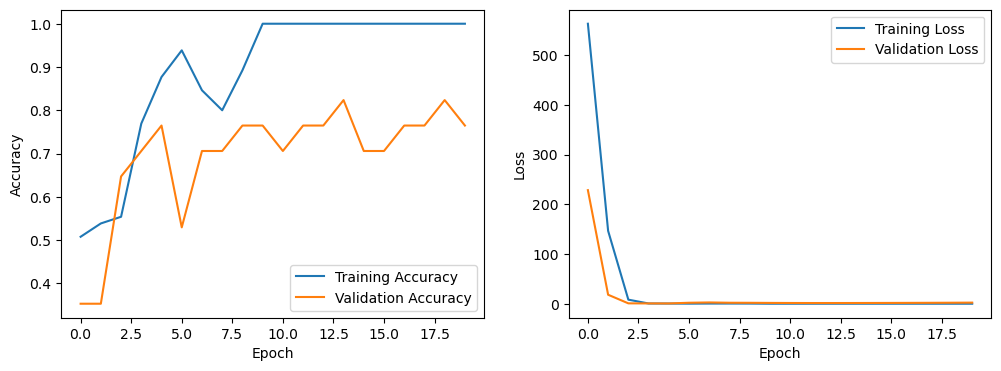

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

# Load and preprocess the images
def load_and_preprocess_images(image_paths, labels):
    images = [tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224)) for img_path in image_paths]
    images = [tf.keras.preprocessing.image.img_to_array(img) for img in images]
    images = [tf.keras.applications.vgg16.preprocess_input(img) for img in images]
    return np.array(images), labels

# Split the data into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['image_path'], data['label'], test_size=0.2, random_state=42)

# Preprocess the images
train_images, train_labels = load_and_preprocess_images(train_data, train_labels)
test_images, test_labels = load_and_preprocess_images(test_data, test_labels)

# Encode labels
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Calculate class weights to handle imbalance
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels_encoded), y=train_labels_encoded)
class_weight_dict = dict(enumerate(class_weights))

# Define a simple CNN model (you can modify and experiment with architecture)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # for binary classification
])

# Compile the model
model.compile(
                # optimizer='adam',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',  # for binary classification
              metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels_encoded, epochs=20, class_weight=class_weight_dict, validation_data=(test_images, test_labels_encoded))

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_images, test_labels_encoded)
print(f'Test Accuracy: {test_accuracy}')

# Display the training and validation accuracy/loss curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


1/1 [==============================] - 0s 354ms/step
Classification Report:
              precision    recall  f1-score   support

    red_head       1.00      0.60      0.75         5
  white_head       0.71      1.00      0.83         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



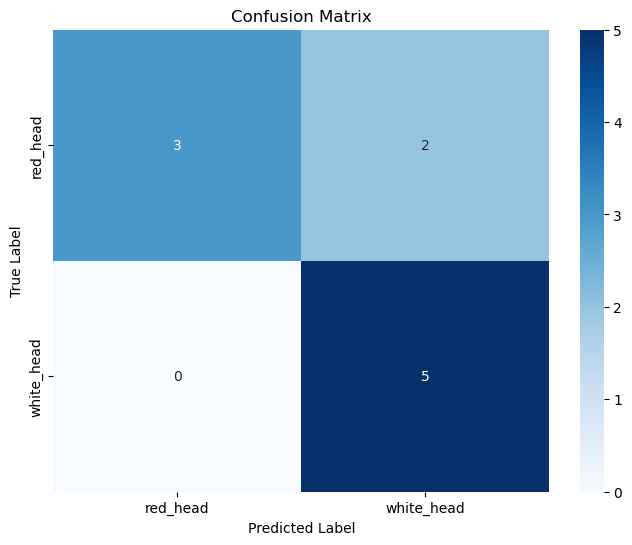

In [29]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Function to load and preprocess test images with subfolders
def load_and_preprocess_test_images(folder_path):
    image_paths = []
    labels = []

    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            for filename in os.listdir(class_folder):
                image_paths.append(os.path.join(class_folder, filename))
                labels.append(class_name)

    images, _ = load_and_preprocess_images(image_paths, labels)
    return images, labels

# Define the path to the unseen data folder
unseen_data_path = r"D:\New folder\prawns segmented data\v3\test"

# Load and preprocess the unseen data
unseen_images, true_labels = load_and_preprocess_test_images(unseen_data_path)

# Make predictions on the unseen data
predictions = model.predict(unseen_images)
predicted_labels = (predictions > 0.5).astype(int).flatten()

# Decode the predicted labels
predicted_class_labels = label_encoder.inverse_transform(predicted_labels)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_class_labels))

# Plot confusion matrix
cm = confusion_matrix(true_labels, predicted_class_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(true_labels), yticklabels=np.unique(true_labels))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
